## Loading Dataset


In [1]:
# IMPORTING DEPENDENCIES
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px 

In [2]:
# LOADING DATA
laptop = pd.read_csv("amazon_laptop_prices_v01.csv")
laptop.head()

,brand,model,screen_size,color,harddisk,cpu,ram,OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price
0,ROKC,NaN,14 Inches,Blue,1000 GB,Intel Core i7,8 GB,Windows 11,NaN,Integrated,Intel,1.2 GHz,NaN,$589.99
1,HP,NaN,15.6 Inches,Silver,1000 GB,Intel Core i5,64 GB,Windows 11 Pro,Backlit Keyboard,Integrated,Intel,NaN,4.5,$999.99
2,MSI,Vector GP66 12UGS-267,15.66 Inches,Core Black,NaN,Intel Core i9,32 GB,Windows 11 Home,NaN,Dedicated,NaN,1.8 GHz,5.0,"$1,599.00"
3,Apple,MacBook Air,13.3 Inches,Silver,256 GB,Unknown,8 GB,Mac OS,Backlit Keyboard,Integrated,NaN,NaN,4.8,$689.99
4,Apple,MacBook Air,15.3 Inches,Midnight,256 GB,Unknown,8 GB,Mac OS,NaN,Integrated,NaN,NaN,4.8,"$1,144.48"


In [3]:
# DATA INFORMATION
print(laptop.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446 entries, 0 to 4445
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 4446 non-null   object 
 1   model                 3282 non-null   object 
 2   screen_size           4417 non-null   object 
 3   color                 3867 non-null   object 
 4   harddisk              3870 non-null   object 
 5   cpu                   4346 non-null   object 
 6   ram                   4385 non-null   object 
 7   OS                    4420 non-null   object 
 8   special_features      2054 non-null   object 
 9   graphics              4381 non-null   object 
 10  graphics_coprocessor  2574 non-null   object 
 11  cpu_speed             1520 non-null   object 
 12  rating                2174 non-null   float64
 13  price                 4441 non-null   object 
dtypes: float64(1), object(13)
memory usage: 486.4+ KB
None


## Data Cleaning and Preparation

In [4]:
# CHECKING FOR MISSING VALUE
print(laptop.isna().sum())

brand                      0
model                   1164
screen_size               29
color                    579
harddisk                 576
cpu                      100
ram                       61
OS                        26
special_features        2392
graphics                  65
graphics_coprocessor    1872
cpu_speed               2926
rating                  2272
price                      5
dtype: int64


In [5]:
# FEATURE SELECTION
column = ['special_features','graphics','graphics_coprocessor', 'harddisk','cpu_speed','color']
laptop = laptop.drop(columns=column)
print(laptop.columns)

Index(['brand', 'model', 'screen_size', 'cpu', 'ram', 'OS', 'rating', 'price'], dtype='object')


In [6]:
# DROPPING MISSING ROW
laptop = laptop.dropna()
print(laptop.isna().sum())

brand          0
model          0
screen_size    0
cpu            0
ram            0
OS             0
rating         0
price          0
dtype: int64


In [7]:
# CONVERTING THE PRICE, SCREEN SIZE, AND RAM COLUMN INTO AN INTEGER
laptop['price'] = laptop['price'].replace('[\$,]', '',regex=True).astype(float)
laptop['screen_size'] = laptop['screen_size'].replace('[Inches/]','',regex=True).astype(float)
laptop['ram'] = laptop['ram'].replace('[GB/]','',regex=True).astype('int64')
print(laptop.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1327 entries, 2 to 4441
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brand        1327 non-null   object 
 1   model        1327 non-null   object 
 2   screen_size  1327 non-null   float64
 3   cpu          1327 non-null   object 
 4   ram          1327 non-null   int64  
 5   OS           1327 non-null   object 
 6   rating       1327 non-null   float64
 7   price        1327 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 93.3+ KB
None


In [8]:
# CHANGING THE FEATURE NAME OF THE DATA 
col = ['brand','model','screen_size(Inches)','cpu','ram(GB)','operating_system','rating','price($)']
laptop.columns = col
laptop.head()

,brand,model,screen_size(Inches),cpu,ram(GB),operating_system,rating,price($)
2,MSI,Vector GP66 12UGS-267,15.66,Intel Core i9,32,Windows 11 Home,5.0,1599.00
3,Apple,MacBook Air,13.30,Unknown,8,Mac OS,4.8,689.99
4,Apple,MacBook Air,15.30,Unknown,8,Mac OS,4.8,1144.48
5,Acer,A315-24P-R7VH,15.60,Ryzen 3,8,Windows 11 S,4.5,299.99
6,Apple,MacBook Pro,13.30,Unknown,8,Mac OS,4.7,965.08


In [9]:
# SHAPE OF DATA
print(laptop.shape)

(1327, 8)


In [10]:
# GROUPING LAPTOP BRAND WITH THEIR TOTAL PRICE
price = laptop.groupby('brand')['price($)'].sum().reset_index()
price

,brand,price($)
0,ASUS,162984.86
1,AWOW,308.42
2,Acer,539.98
3,Alienware,22216.60
4,Apple,21515.66
5,Asus,637.49
6,Carlisle FoodService Products,134.90
7,Corsair,1699.99
8,DELL,2638.99
9,Dell,349274.91


In [11]:
# VISUALIZING LAPTOP BRAND WITH THEIR TOTAL PRICE
fig = px.line(price, x='brand',y='price($)', title='TOTAL PRICE BY BRANDS')
fig.show()

In [12]:
# GROUPING LAPTOP MODEL WITH THE TOTAL PRICE >= 7000
high_value = laptop.groupby('model')['price($)'].sum().reset_index()
price_7k = high_value[high_value['price($)']>=7000].sort_values(by='price($)',ascending=True)
price_7k

,model,price($)
478,Raider GE76 12UHS-255,7198.00
594,WS66 10TMT-207,7399.00
355,Latitude 5420,7722.07
142,Blade 15,8058.67
302,HP Spectre,9196.00
350,Latitude 5000,9777.92
218,Dell XPS,10108.53
201,Dell Inspiron,10524.84
324,Inspiron,11037.77
209,Dell Latitude,11984.36


In [13]:
# VISUALIZING LAPTOP MODEL WITH THE TOTAL PRICE >= 7000
fig = px.bar(price_7k, x='price($)',y='model', color='model',title='TOTAL PRICE BY MODEL GREATER THAN OR EQUAL 7K')
fig.show()

In [14]:
# RATING
rate = laptop.groupby('brand')['rating'].mean().reset_index().sort_values(by='rating',ascending=True)
rate

,brand,rating
11,GizPro,2.500000
7,Corsair,2.600000
22,MSI,3.150463
19,Latitude,3.200000
12,Goldengulf,3.500000
36,lenovo,3.500000
1,AWOW,3.500000
25,Quality Refurbished Computers,3.700000
34,asus,3.700000
14,IVIEW,3.700000


In [15]:
# AVERAGE RATING BY BRAND
fig = px.bar(rate, x='brand',y='rating',title='AVERAGE RATING BY BRAND')
fig.show()

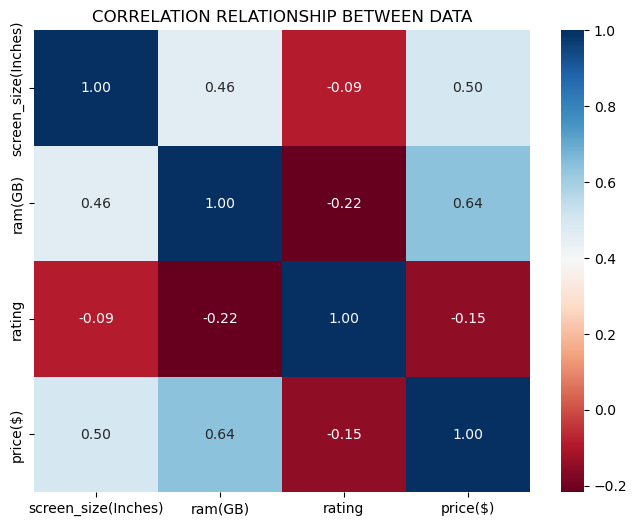

In [16]:
# CORRELATION OF THE NUMERICAL FEATURE
cor_col = ['screen_size(Inches)','ram(GB)','rating','price($)']
laptop_corr = laptop[cor_col].corr()
plt.figure(figsize=(8,6))
sns.heatmap(laptop_corr, annot=True,cmap='RdBu',fmt='.2f')
plt.title('CORRELATION RELATIONSHIP BETWEEN DATA')
plt.show()